# instalação das bibliotecas

In [1]:
install.packages("ggplot2")
install.packages("scales")
install.packages("poweRlaw")

Instalando pacote em 'C:/Users/atila/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

instalando as dependências 'farver', 'labeling', 'RColorBrewer', 'viridisLite', 'gtable', 'isoband', 'S7', 'scales' também




pacote 'farver' desempacotado com sucesso e somas MD5 verificadas
pacote 'labeling' desempacotado com sucesso e somas MD5 verificadas
pacote 'RColorBrewer' desempacotado com sucesso e somas MD5 verificadas
pacote 'viridisLite' desempacotado com sucesso e somas MD5 verificadas
pacote 'gtable' desempacotado com sucesso e somas MD5 verificadas
pacote 'isoband' desempacotado com sucesso e somas MD5 verificadas
pacote 'S7' desempacotado com sucesso e somas MD5 verificadas
pacote 'scales' desempacotado com sucesso e somas MD5 verificadas
pacote 'ggplot2' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\atila\AppData\Local\Temp\RtmpAT13Nm\downloaded_packages


Instalando pacote em 'C:/Users/atila/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)



pacote 'scales' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\atila\AppData\Local\Temp\RtmpAT13Nm\downloaded_packages


Instalando pacote em 'C:/Users/atila/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

instalando a dependência 'pracma' também




pacote 'pracma' desempacotado com sucesso e somas MD5 verificadas
pacote 'poweRlaw' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\atila\AppData\Local\Temp\RtmpAT13Nm\downloaded_packages


# importação das bibliotecas

In [2]:
library(ggplot2)
library(scales)
library(poweRlaw)

# leitura do arquivo csv tratado usando `algs4 (java)`

Colunas:
- Vertice: posição do vértice
- Grau: Grau do respectivo vértice

## Sobre o tratamento:
- Remoção de arestas duplicadas
- Manteve self-loops

Exemplo de aresta duplicada:

```
Source Target
0 1
2 3
...
1 0
``

In [5]:
#dados <- read.csv("/content/sample_data/arestas_sem_duplicacao.csv")
dados <- read.csv("./grau_vertices.csv")
graus <- dados$Grau
#list.files()
dados

Vertice,Grau
<int>,<int>
0,23
1,1
2,100
3,30
4,4
5,1
6,30
7,30
8,10


# Estatística do dataset

In [6]:
# CORRETO
# =====================================
# CHECKPOINT 1
# Estatísticas do grafo
# =====================================

num_vertices <- length(graus)

num_arestas <- sum(graus) / 2

grau_medio <- mean(graus)

densidade <- (2 * num_arestas) / (num_vertices * (num_vertices - 1))

cat("===== ESTATÍSTICAS DO GRAFO =====\n")
cat("Número de vértices:", num_vertices, "\n")
cat("Número de arestas:", num_arestas, "\n")
cat("Grau médio:", grau_medio, "\n")
cat("Densidade:", densidade, "\n")
cat("Grau mínimo:", min(graus), "\n")
cat("Grau máximo:", max(graus), "\n")

===== ESTATÍSTICAS DO GRAFO =====
Número de vértices: 11631 
Número de arestas: 170918 
Grau médio: 29.39008 
Densidade: 0.002527092 
Grau mínimo: 1 
Grau máximo: 3546 


# Gráfico - Histograma do dataset

Eixos:
- Eixo X: Grau do vértice
- Eixo Y: Frequência

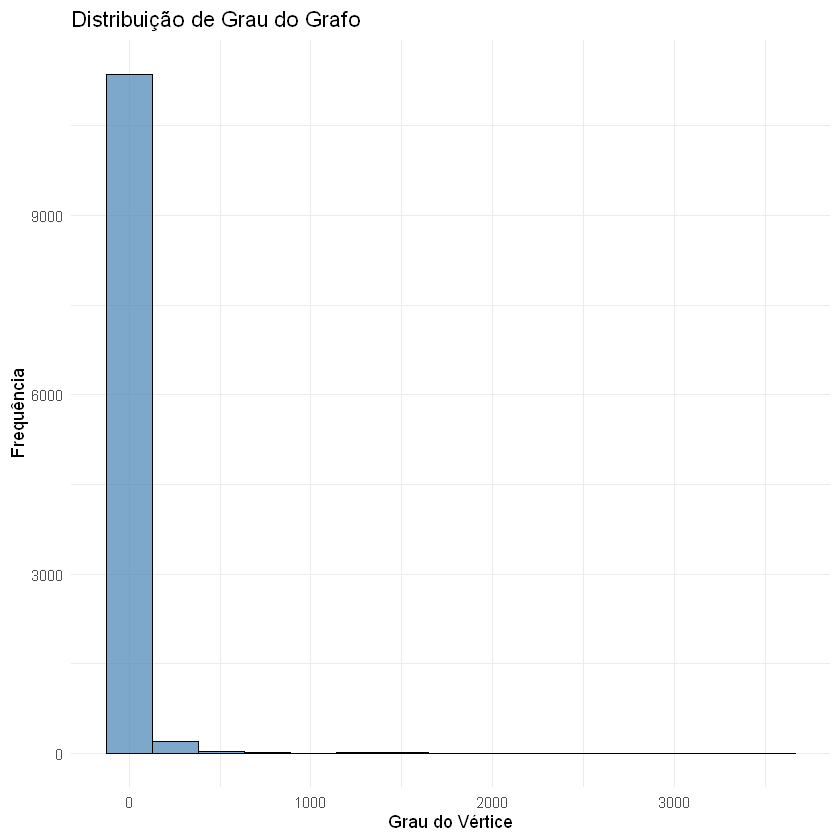

In [7]:
# Histograma frequência x grau

n_bins <- nclass.Sturges(dados$Grau)


ggplot(dados, aes(x = Grau)) +
  geom_histogram(
    bins= n_bins,
    fill = "steelblue",
    color = "black",
    alpha = 0.7
  ) +
  labs(
    title = "Distribuição de Grau do Grafo",
    x = "Grau do Vértice",
    y = "Frequência"
  ) +
  theme_minimal()


# Gráfico - Distribuição de graus: Escala Linear
Eixos:
- Eixo x: Grau do vértice
- Eixo y: Probabilidade

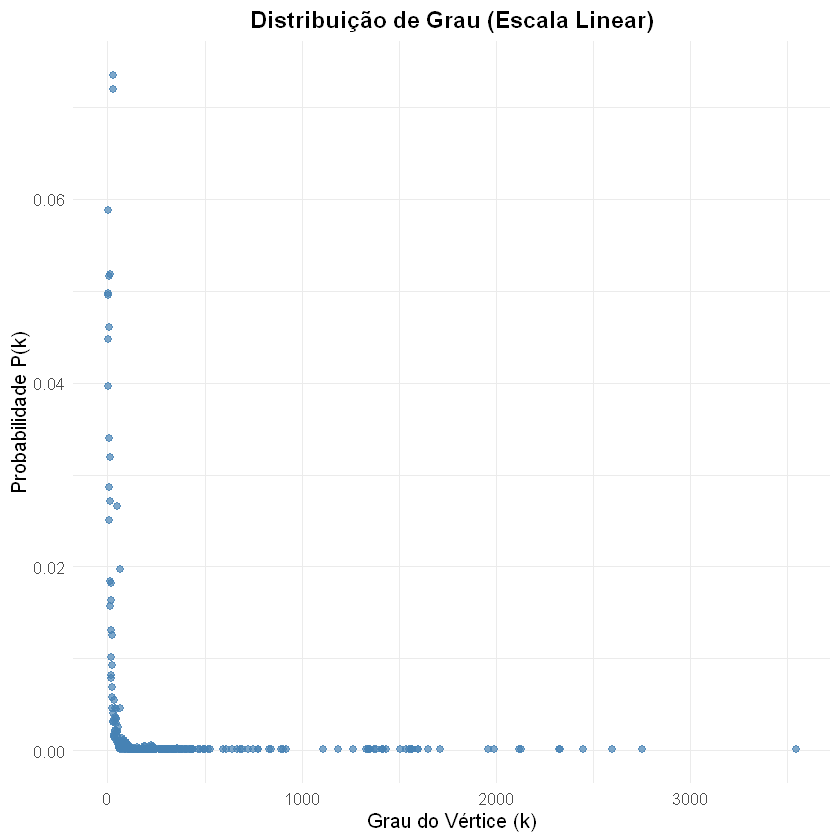

In [8]:
# =====================================
# CHECKPOINT 2
# Histograma log-log
# =====================================

tabela_graus <- table(graus)

grau <- as.numeric(names(tabela_graus))

probabilidade <- as.numeric(tabela_graus) / sum(tabela_graus)

distribuicao <- data.frame(Grau = grau, Probabilidade = probabilidade)

ggplot(distribuicao, aes(x = Grau, y = Probabilidade)) +
  geom_point(
    color = "steelblue",  # Cor azul similar ao gráfico
    size = 2,             # Tamanho dos pontos
    alpha = 0.7           # Transparência
  ) +
  labs(
    title = "Distribuição de Grau (Escala Linear)",
    x = "Grau do Vértice (k)",
    y = "Probabilidade P(k)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.title = element_text(size = 12),
    axis.text = element_text(size = 10)
  )

# Gráfico - Distribuição de graus: Escala Log-Log
Eixos:
- Eixo x: log(Grau do vértice)
- Eixo y: log(Probabilidade)

Warning message:
"The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."


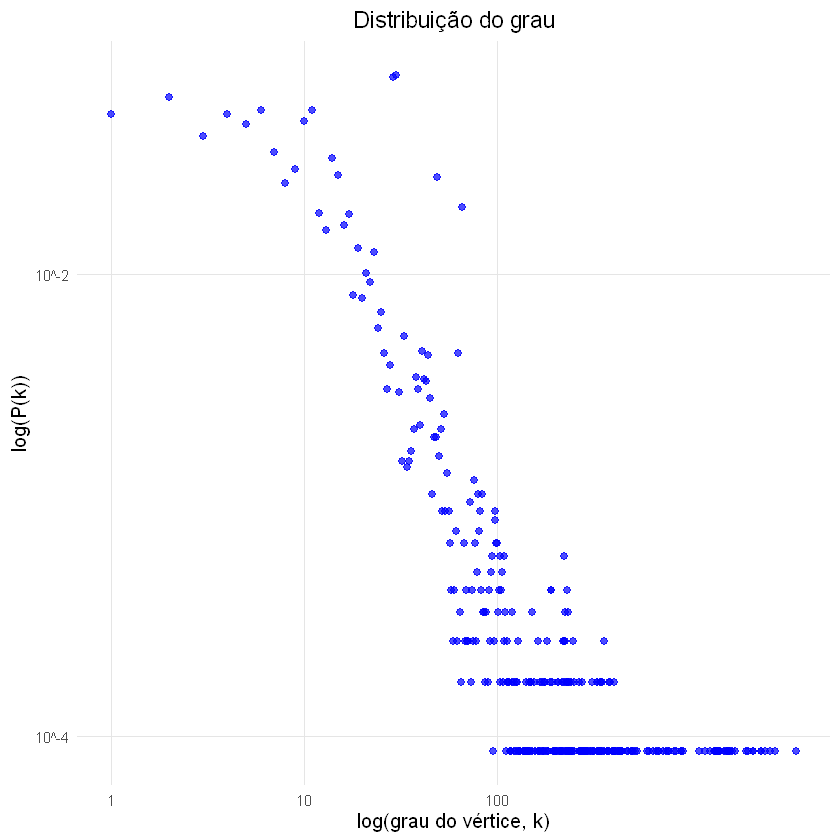

In [9]:
ggplot(distribuicao, aes(x = Grau, y = Probabilidade)) +
  geom_point(
    color = "blue",        # Pontos azuis como no gráfico anexado
    size = 2,              # Tamanho dos pontos
    alpha = 0.7            # Transparência leve
  ) +
  scale_x_log10(
    breaks = c(1, 10, 100),  # Escala logarítmica no eixo x
    labels = c("1", "10", "100")
  ) +
  scale_y_log10(
    breaks = c(1e-4, 1e-2, 1),  # Escala logarítmica no eixo y
    labels = c("10^-4", "10^-2", "10^0")
  ) +
  labs(
    title = "Distribuição do grau",  # Título igual ao anexado
    x = "log(grau do vértice, k)",           # Rótulo do eixo x igual
    y = "log(P(k))"            # P_k como no gráfico
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),  # Remove grid menor
    panel.grid.major = element_line(color = "grey90", size = 0.2),  # Grid suave
    plot.title = element_text(hjust = 0.5, size = 14),  # Título centralizado
    axis.title = element_text(size = 12)
  )

In [10]:
modelo_powerlaw <- displ$new(graus)

xmin_power <- estimate_xmin(modelo_powerlaw)

modelo_powerlaw$setXmin(xmin_power)

pars_power <- estimate_pars(modelo_powerlaw)

modelo_powerlaw$setPars(pars_power)

# Modelo Log-normal

modelo_lognormal <- dislnorm$new(graus)

modelo_lognormal$setXmin(modelo_powerlaw$getXmin())

pars_ln <- estimate_pars(modelo_lognormal)

modelo_lognormal$setPars(pars_ln)

# =====================================
# Gráfico do ajuste Log-normal
# =====================================

#plot(modelo_lognormal,
#     main = "Distribuição de Grau com Ajuste Log-normal",
#     xlab = "Grau",
#     ylab = "Probabilidade")

#lines(modelo_lognormal, col = "blue", lwd = 2)

#plot(modelo_powerlaw,
#     main = "Distribuição de Grau com Ajuste Log-normal",
#     xlab = "Grau",
#     ylab = "Probabilidade")

#lines(modelo_powerlaw, col = "blue", lwd = 2)

# =====================================
# Comparação entre modelos
# =====================================

comparacao <- compare_distributions(modelo_powerlaw, modelo_lognormal)

R <- comparacao$test_statistic

p_value <- comparacao$p_two_sided

# =====================================
# Mostrar resultados
# =====================================

cat("\n===== RESULTADOS DO AJUSTE =====\n")

cat("xmin:", xmin_power$xmin, "\n")

cat("alpha (power law):", pars_power$pars, "\n")

cat("Log-likelihood ratio (R):", R, "\n")

cat("p-value:", p_value, "\n")

nós_acima_xmin <- sum(graus >= xmin_power$xmin)
total_nós <- length(graus)
percentual <- (nós_acima_xmin / total_nós) * 100

cat("\n=== ANÁLISE DO XMIN ===\n")
cat("Nós com grau ≥", xmin_power$xmin, ":", nós_acima_xmin, "\n")
cat("Total de nós:", total_nós, "\n")
cat("Percentual:", round(percentual, 2), "%\n")

dados_acima_xmin <- graus[graus >= xmin_power$xmin]


===== RESULTADOS DO AJUSTE =====
xmin: 67 
alpha (power law): 2.0752 
Log-likelihood ratio (R): -1.687887 
p-value: 0.0914329 

=== ANÁLISE DO XMIN ===
Nós com grau ≥ 67 : 548 
Total de nós: 11631 
Percentual: 4.71 %


# Função: Identificação de outliers
Método Tukey

In [11]:
# =====================================
# FUNÇÃO MELHORADA PARA IDENTIFICAR OUTLIERS
# =====================================

identificar_outliers_refinado <- function(graus, metodo = "iqr", limite = 1.5) {
  # Usar limite mais conservador (3.0 em vez de 1.5)

  if (metodo == "iqr") {
    # Método IQR com limite mais conservador
    Q1 <- quantile(graus, 0.25)
    Q3 <- quantile(graus, 0.75)
    IQR <- Q3 - Q1

    # Limites mais amplos
    limite_inferior <- Q1 - limite * IQR
    limite_superior <- Q3 + limite * IQR

    # Identificar outliers (valores individuais, não todos do mesmo grau)
    is_outlier <- graus < limite_inferior | graus > limite_superior

    return(list(
      outliers = graus[is_outlier],
      indices_outliers = which(is_outlier),
      limite_inferior = limite_inferior,
      limite_superior = limite_superior,
      total_outliers = sum(is_outlier)
    ))
  }
}

# Identificando outliers

In [12]:
# =====================================
# CÓDIGO CORRIGIDO
# =====================================

# 1. Identificar outliers de forma mais conservadora
#resultado_outliers <- identificar_outliers_refinado(dados_acima_xmin, metodo = "iqr", limite = 1.5)
resultado_outliers <- identificar_outliers_refinado(graus, metodo = "iqr", limite = 1.5)

cat("Número de outliers identificados:", resultado_outliers$total_outliers, "\n")
#cat(resultado_outliers$outliers)
cat("Limite inferior:", resultado_outliers$limite_inferior, "\n")
cat("Limite superior:", resultado_outliers$limite_superior, "\n")

graus_filtrados <- graus[!graus %in% resultado_outliers$outliers]

# 2. Filtrar dados (mantendo apenas acima do xmin)
#graus_filtrados <- graus_filtrados[graus_filtrados >= xmin_power$xmin]

# 3. Remover outliers (apenas os valores individuais identificados)
# NÃO remover todos os valores do mesmo grau!
#graus_filtrados <- graus_filtrados[!graus_filtrados %in% resultado_outliers$outliers]

cat("\n===== RESULTADOS =====\n")
cat("Dados originais:", length(graus), "\n")
cat("Dados após filtro (outliers):", length(graus_filtrados), "\n")
#cat("Dados após filtro (xmin):", length(graus_filtrados), "\n")
cat("Porcentagem mantida:", round(length(graus_filtrados)/length(graus)*100, 2), "%\n")


Número de outliers identificados: 783 
Limite inferior: -28.5 
Limite superior: 63.5 

===== RESULTADOS =====
Dados originais: 11631 
Dados após filtro (outliers): 10848 
Porcentagem mantida: 93.27 %


xmin: 8
===== ESTATÍSTICAS DA DISTRIBUIÇÃO FILTRADA =====
Número de graus únicos: 56 
Grau mínimo: 8 
Grau máximo: 63 


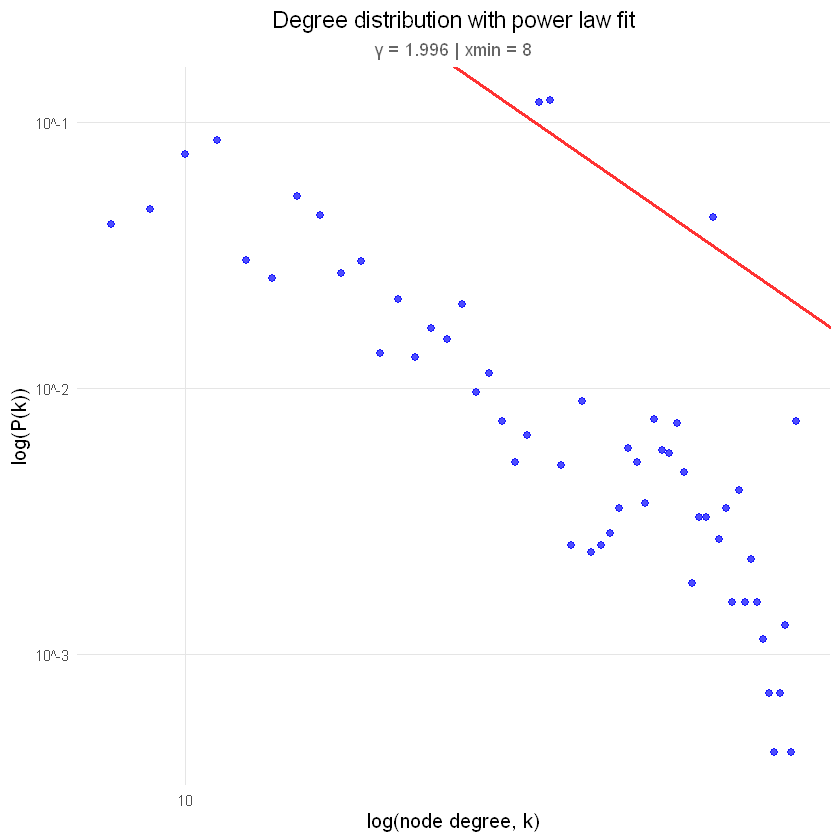

In [14]:
modelo_powerlaw_filtrado <- displ$new(graus_filtrados)

xmin_power_filtrado <- estimate_xmin(modelo_powerlaw_filtrado)

modelo_powerlaw$setXmin(xmin_power_filtrado)

pars_power_filtrado <- estimate_pars(modelo_powerlaw_filtrado)

modelo_powerlaw$setPars(pars_power_filtrado)

cat("xmin:", xmin_power_filtrado$xmin)

dados_acima_xmin <- graus_filtrados[graus_filtrados >= xmin_power_filtrado$xmin]

tabela_graus_filt <- table(dados_acima_xmin)
grau_filt <- as.numeric(names(tabela_graus_filt))
probabilidade_filt <- as.numeric(tabela_graus_filt) / sum(tabela_graus_filt)

# Criar dataframe filtrado
distribuicao_filtrada <- data.frame(
  Grau = grau_filt,
  Probabilidade = probabilidade_filt
)

cat("\n===== ESTATÍSTICAS DA DISTRIBUIÇÃO FILTRADA =====\n")
cat("Número de graus únicos:", nrow(distribuicao_filtrada), "\n")
cat("Grau mínimo:", min(distribuicao_filtrada$Grau), "\n")
cat("Grau máximo:", max(distribuicao_filtrada$Grau), "\n")

log_grau <- log(distribuicao_filtrada$Grau)
log_prob <- log(distribuicao_filtrada$Probabilidade)
modelo_regressao <- lm(log_prob ~ log_grau)

gamma <- -coef(modelo_regressao)[2]  # Expoente γ
intercepto <- coef(modelo_regressao)[1]

ggplot(distribuicao_filtrada, aes(x = Grau, y = Probabilidade)) +
  geom_point(
    color = "blue",
    size = 2,
    alpha = 0.7
  ) +
  geom_abline(
    intercept = intercepto,
    slope = -gamma,
    color = "red",
    linewidth = 1,
    linetype = "solid",
    alpha = 0.8
  ) +
  scale_x_log10(
    breaks = c(1, 10, 100, 1000),
    labels = c("1", "10", "100", "1000")
  ) +
  scale_y_log10(
    breaks = c(1e-4, 1e-3, 1e-2, 1e-1, 1),
    labels = c("10^-4", "10^-3", "10^-2", "10^-1", "10^0")
  ) +
  labs(
    title = "Degree distribution with power law fit",
    subtitle = paste("γ =", round(gamma, 3), "| xmin =", xmin_power_filtrado$xmin),
    x = "log(node degree, k)",
    y = "log(P(k))"
  ) +
  theme_minimal() +
  theme(
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    plot.title = element_text(hjust = 0.5, size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 11, color = "gray40"),
    axis.title = element_text(size = 12)
  )

